# Warning :
# Do "File -> Save a copy in Drive" before you start modifying the notebook, otherwise your modifications will not be saved.


In [1]:
import argparse
import os
import time

import PIL
from PIL import Image

import numpy as np
import torchvision
import pickle

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.autograd import Variable

from sklearn.svm import LinearSVC

# Partie 1 : Architecture VGG16

In [ ]:
# #!wget https://github.com/cdancette/deep-learning-polytech-tp6-7/raw/master/tp8/imagenet_classes.pkl
# !wget https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/imagenet_classes.pkl

# # Bonus : Classifiez des exemples avec vgg16 et commentez le résultat dans votre rapport.
# !wget --content-disposition https://unsplash.com/photos/gKXKBY-C-Dk/download?force=true -O cat.jpg
# !wget --content-disposition https://unsplash.com/photos/qO-PIF84Vxg/download?force=true -O dog.jpg

'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# # Download imagenet_classes.pkl
# # !wget https://github.com/cdancette/deep-learning-polytech-tp6-7/raw/master/tp8/imagenet_classes.pkl
# !curl -L -o imagenet_classes.pkl https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/imagenet_classes.pkl

# # Bonus : Classifiez des exemples avec vgg16 et commentez le résultat dans votre rapport.
# !curl -L --output cat.jpg https://unsplash.com/photos/gKXKBY-C-Dk/download?force=true
# !curl -L --output dog.jpg https://unsplash.com/photos/qO-PIF84Vxg/download?force=true

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  3 35454    3  1378    0     0   3409      0  0:00:10 --:--:--  0:00:10  3409
100 35454  100 35454    0     0  86902      0 --:--:-- --:--:-- --:--:-- 10.8M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:03 --:--:--     0
  0     0    0     0    0     0      0      0 --:

In [2]:
a = torch.Tensor([1, 2, 3])
print(a.view(3,1,1))

tensor([[[1.]],

        [[2.]],

        [[3.]]])


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


(1, 1000)
prediction: Egyptian cat


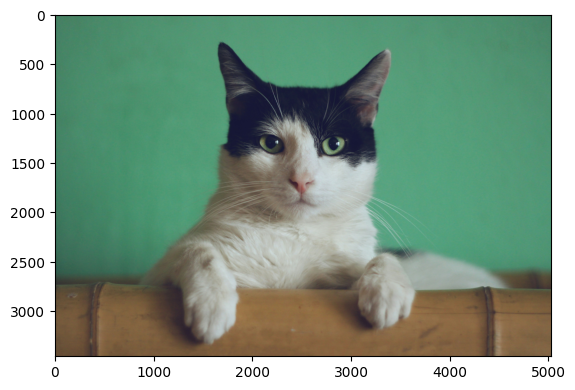

In [3]:
nameim = "cat"+".jpg"
#cat = Image.open('cat.jpg')
img = Image.open(nameim)
plt.imshow(img)

# Loading ImageNet classes
imagenet_classes = pickle.load(open('imagenet_classes.pkl', 'rb'))

# Normalization
img = img.resize((224, 224), Image.BILINEAR)
img = np.array(img, dtype=np.float32) / 255
img = img.transpose((2, 0, 1))
# ImageNet mean/std
mu = torch.Tensor([0.485, 0.456, 0.406])
sigma = torch.Tensor([0.229, 0.224, 0.225])
# Expand mu & sigma to match image size
mu = mu.view(3, 1, 1)
sigma = sigma.view(3, 1, 1)
# compute the normalized image with mean ImageNet image
img = (img - mu.numpy()) / sigma.numpy()

# Loding pre-trained VGG
vgg16 = torchvision.models.vgg16(pretrained=True)
vgg16.eval() # WHY THAT ?

# Forward pass on VGG
img = np.expand_dims(img, 0)
x = torch.Tensor(img)
y = vgg16(x) # TODO calcul forward
y = y.detach().numpy() # transformation en array numpy
print(y.shape)
# Get prediction (i.e., ImageNet class label)
y = np.argmax(y)
print("prediction:",imagenet_classes[y])

# Partie 2: Transfer Learning avec VGG16 sur 15 Scene

In [ ]:
# #!wget https://github.com/cdancette/deep-learning-polytech-tp6-7/raw/master/tp8/15ScenesData.zip
# !wget https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/15ScenesData.zip

# !unzip 15ScenesData.zip

In [ ]:
# Download the 15ScenesData.zip file
# !wget https://github.com/cdancette/deep-learning-polytech-tp6-7/raw/master/tp8/15ScenesData.zip
!curl -L -o 15ScenesData.zip https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/15ScenesData.zip

# Unzip the 15ScenesData.zip file
!tar -xf 15ScenesData.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0 82.5M    0  131k    0     0   135k      0  0:10:23 --:--:--  0:10:23  135k
  0 82.5M    0  227k    0     0  90111      0  0:16:00  0:00:02  0:15:58 60869
  0 82.5M    0  275k    0     0  94940      0  0:15:11  0:00:02  0:15:09 73691
  0 82.5M    0  403k    0     0   101k      0  0:13:55  0:00:03  0:13:52 92227
  0 82.5M    0  531k    0     0   106k      0  0:13:16  0:00:05  0:13:11   99k
  0 82.5M    0  563k    0     0  96619      0  0:14:55  0:00:05  0:14:50 88438
  0 82.5M    0  563k    0     0  82732      0  0:17:25  0:00:06  0:17:19 78374
  0 82.5M    0  595k    0     0  69290      0  0:20:48  0:00:08  0:20:40 56215
  0 82.5M    0  595k    0     0  62531      0  0:2

In [ ]:
# ls 15SceneData/test/bedroom/
!dir 15SceneData\test\bedroom\

 Volume in drive C is Windows-SSD
 Volume Serial Number is C85B-67C7

 Directory of c:\Users\User\Desktop\RDFIA\TME1\section2\15SceneData\test\bedroom

09/11/2019  11:18 AM    <DIR>          .
09/11/2019  11:41 AM    <DIR>          ..
10/13/2011  11:41 PM            38,116 image_0003.jpg
10/13/2011  11:41 PM            33,261 image_0004.jpg
10/13/2011  11:41 PM            36,725 image_0006.jpg
10/13/2011  11:41 PM            27,436 image_0007.jpg
10/13/2011  11:41 PM            41,706 image_0008.jpg
10/13/2011  11:41 PM            36,556 image_0011.jpg
10/13/2011  11:41 PM            40,899 image_0013.jpg
10/13/2011  11:41 PM            36,267 image_0014.jpg
10/13/2011  11:41 PM            36,451 image_0016.jpg
10/13/2011  11:41 PM            31,893 image_0017.jpg
10/13/2011  11:41 PM            37,411 image_0018.jpg
10/13/2011  11:41 PM            44,659 image_0019.jpg
10/13/2011  11:41 PM            38,530 image_0020.jpg
10/13/2011  11:41 PM            32,942 image_0021.jpg
10/13/201

In [4]:
class VGG16relu7(nn.Module):
  def __init__(self, vgg16):
    super(VGG16relu7, self).__init__()
    # Copy the entire convolutional part
    self.features = nn.Sequential( *list(vgg16.features.children()))
    # Keep a piece of the classifier: -2 to stop at relu7
    self.classifier = nn.Sequential(*list(vgg16.classifier.children())[:-2])
    
  def forward(self, x):
    x = self.features(x)
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [5]:
# print(vgg16.features)
print(vgg16.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


In [6]:

PRINT_INTERVAL = 50
CUDA = False

def duplicateChannel(img):
    img = img.convert('L')
    np_img = np.array(img, dtype=np.uint8)
    np_img = np.dstack([np_img, np_img, np_img])
    img = Image.fromarray(np_img, 'RGB')
    return img

def resizeImage(img):
      return img.resize((224,224), Image.BILINEAR)

def get_dataset(batch_size, path):

    # This function expands 3 times a gray level image
    # to transform it into an image RGB. Use it with transform.Lambda

    
    

    #####################
    ## YOUR CODE HERE  ##
    #####################
    # Add pre-processing
    # Pre-processing TODO: duplicateChannel(), resizeImage(), toTensor(), Normalize ()
    train_dataset = datasets.ImageFolder(path+'/train',
        transform=transforms.Compose([ transforms.Lambda(duplicateChannel),transforms.Lambda(resizeImage), transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
        ]))
    val_dataset = datasets.ImageFolder(path+'/test',
        transform=transforms.Compose([ transforms.Lambda(duplicateChannel),transforms.Lambda(resizeImage), transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
        ]))
    ####################
    ##      END        #
    ####################

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=CUDA, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=CUDA, num_workers=2)

    return train_loader, val_loader

In [7]:
CUDA = True

if CUDA:
    print(torch.cuda.is_available())
    print("Device name: ", torch.cuda.get_device_name(0))

True
Device name:  NVIDIA GeForce RTX 3050 Laptop GPU


In [17]:
def extract_features(data, model):
    # init features matrices
    X = []
    y = []
   
    for i, (input, target) in enumerate(data):
        print(i, " ## ")
        if i % PRINT_INTERVAL == 0:
            print('Batch {0:03d}/{1:03d}'.format(i, len(data)))
        if CUDA:
            input = input.cuda()
       
        # Feature extraction à faire
        X.append(model(input).detach().cpu().numpy())
        y.append(target.detach().cpu().numpy())
        

    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)

    return X, y

In [ ]:
def main(path="15SceneData", batch_size=8):
    print('Instanciation de VGG16')
    vgg16 = models.vgg16(pretrained=True)

    print('Instanciation de VGG16relu7')
    #####################
    ## YOUR CODE HERE  ##
    #####################
    # Remplacer par le modèle par un réseau tronqué pour faire de la feature extraction
    # On créera une nouvelle classe VGG16relu7 ici
    model = VGG16relu7(vgg16)
    ####################
    ##      END        #
    ####################

    model.eval()
    if CUDA: # si on fait du GPU, passage en CUDA
        cudnn.benchmark = True
        model = model.cuda()

    # On récupère les données
    print('Récupération des données')
    train, test = get_dataset(batch_size, path)

    # Extraction des features
    print('Feature extraction')
    X_train, y_train = extract_features(train, model)
    X_test, y_test = extract_features(test, model)

    #####################
    ## Votre code ici  ##
    #####################

    # Apprentissage et évaluation des SVM à faire
    print('Apprentissage des SVM')
    svm = LinearSVC(C=1.0)
    svm.fit(X_train, y_train)
    accuracy = svm.score(X_test, y_test)
    ####################
    ##      FIN        #
    ####################
    print('Accuracy = %f' % accuracy)


In [ ]:
main("15SceneData", 8)

Instanciation de VGG16


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Instanciation de VGG16relu7
Récupération des données
Feature extraction


# Going further 

## • Change the layer at which the features are extracted.

## • Tune the parameter C to improve performance.

In [10]:
path="15SceneData"
batch_size=8
print('Instanciation de VGG16')
vgg16 = models.vgg16(pretrained=True)

print('Instanciation de VGG16relu7')
model = VGG16relu7(vgg16)

model.eval()
if CUDA: # si on fait du GPU, passage en CUDA
    cudnn.benchmark = True
    model = model.cuda()

# On récupère les données
print('Récupération des données')
train, test = get_dataset(batch_size, path)

Instanciation de VGG16
Instanciation de VGG16relu7
Récupération des données


In [14]:
print(len(train.dataset))
print(len(test.dataset.classes))

1500
15


features extraction

In [ ]:
# Extraction des features
print('Feature extraction')
X_train, y_train = extract_features(train, model)
X_test, y_test = extract_features(test, model)


Feature extraction


tuning svm C parameter

In [ ]:
def tune_C(X_train, y_train, X_test, y_test, C_values):
    best_C = None
    best_accuracy = 0.0
    
    # Loop through each C value and train an SVM
    for C in C_values:
        print(f"Training with C={C}")
        svm = LinearSVC(C=C, max_iter=10000)  # Increased max_iter to ensure convergence
        svm.fit(X_train, y_train)  # Fit model on the training data
        
        # Calculate accuracy on the test set
        accuracy = svm.score(X_test, y_test)
        print(f"Accuracy for C={C}: {accuracy}")
        
        # Update best_C if this model performs better
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_C = C
    
    print(f"\nBest C: {best_C} with Accuracy: {best_accuracy}")
    return best_C, best_accuracy

In [ ]:
print('Tuning SVM C parameter')
C_values = [0.001, 0.01, 0.1, 1.0, 10, 100]  # Range of C values to try
best_C, best_accuracy = tune_C(X_train, y_train, X_test, y_test, C_values)

print(f'Best accuracy: {best_accuracy} with C={best_C}')